In [1]:
import numpy as np
import random
from pymoo.core.problem import Problem
from pymoo.problems import get_problem
from pymoo.visualization.util import plot
from pymoo.visualization.scatter import Scatter

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

# Base

In [2]:
class TSPProblem(Problem):
    def __init__(self, n_cities, seed=50):
        # Define the number of variables (cities) and objectives (time and distance)
        super().__init__(n_var=n_cities, n_obj=2, n_constr=0, xl=0, xu=1)

        # Initialize the random seed for reproducibility
        if seed is not None:
            np.random.seed(seed)

        # Generate random distances and times between cities
        self.distances = np.random.uniform(0, 100, size=(n_cities, n_cities))
        self.distances = (self.distances + self.distances.T) / 2
        self.times = np.random.uniform(0, 300, size=(n_cities, n_cities))
        random.seed(None)

        # Ensure the diagonal is zero (distance/time from a city to itself is zero)
        np.fill_diagonal(self.distances, 0)
        np.fill_diagonal(self.times, 0)

    def _evaluate(self, x, out, *args, **kwargs):
        # Calculate the total distance and time for each solution in x
        distances = []
        times = []

        for route in x:
            perm = np.argsort(route)
            total_distance = 0
            total_time = 0

            for i in range(len(perm) - 1):
                total_distance += self.distances[perm[i], perm[i + 1]]
                total_time += self.times[perm[i], perm[i + 1]]

            # Add distance and time from last city back to the first city
            total_distance += self.distances[perm[-1], perm[0]]
            total_time += self.times[perm[-1], perm[0]]

            distances.append(total_distance)
            times.append(total_time)

        out["F"] = np.column_stack([distances, times])

In [9]:
problem = TSPProblem(100, seed=42)
print(np.shape(problem.distances))
print(np.shape(problem.times))

(100, 100)
(100, 100)


In [19]:
algorithm = NSGA2(pop_size=100)
algorithm2 = NSGA2(pop_size=50)
res_batir_1 = minimize(problem, algorithm, ("n_gen", 100), verbose=False)
res_batir_2 = minimize(problem, algorithm2, ("n_gen", 200), verbose=False)

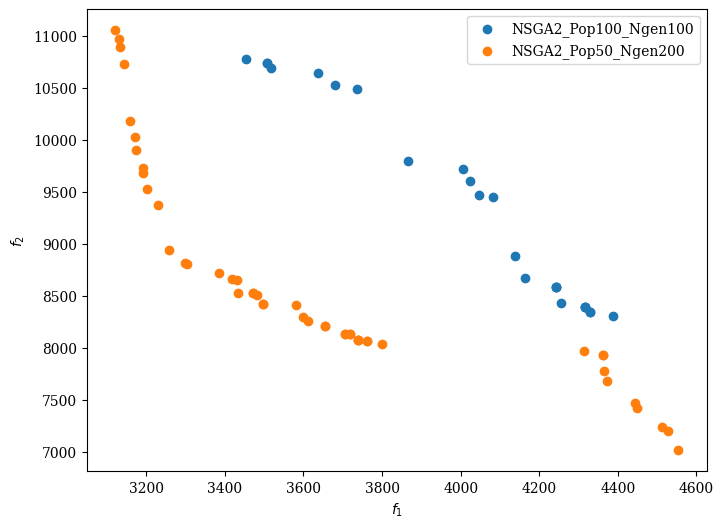

In [21]:
scatter = Scatter()
scatter.add(res_batir_1.F, label="NSGA2_Pop100_Ngen100")
scatter.add(res_batir_2.F, label="NSGA2_Pop50_Ngen200")
scatter.legend = True
scatter.show()

## Custom

In [24]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling

In [27]:
ga = GA(pop_size=100, sampling=PermutationRandomSampling(),      # Muestreo aleatorio de permutaciones
    crossover=OrderCrossover(prob=0.9),         # Order Crossover (ideal para TSP)
    mutation=InversionMutation(prob=0.1),       # Mutación por inversión
    eliminate_duplicates=True)

In [29]:
# Usar NSGA2 en lugar de GA (multi-objetivo)
nsga2_custom_ops = NSGA2(
    pop_size=100,
    sampling=PermutationRandomSampling(),      # Muestreo aleatorio de permutaciones
    crossover=OrderCrossover(prob=0.9),         # Order Crossover (ideal para TSP)
    mutation=InversionMutation(prob=0.1),       # Mutación por inversión
    eliminate_duplicates=True
)

res_1 = minimize(
    problem,
    nsga2_custom_ops,
    ("n_evals", 100000),
    seed=42,
    verbose=False
)

print(f"Soluciones en el frente de Pareto (NSGA-II Custom): {len(res_1.F)}")
print(f"Mejor distancia encontrada: {res_1.F[:, 0].min():.2f}")
print(f"Mejor tiempo encontrado: {res_1.F[:, 1].min():.2f}")

Soluciones en el frente de Pareto (NSGA-II Custom): 72
Mejor distancia encontrada: 3089.38
Mejor tiempo encontrado: 8501.14


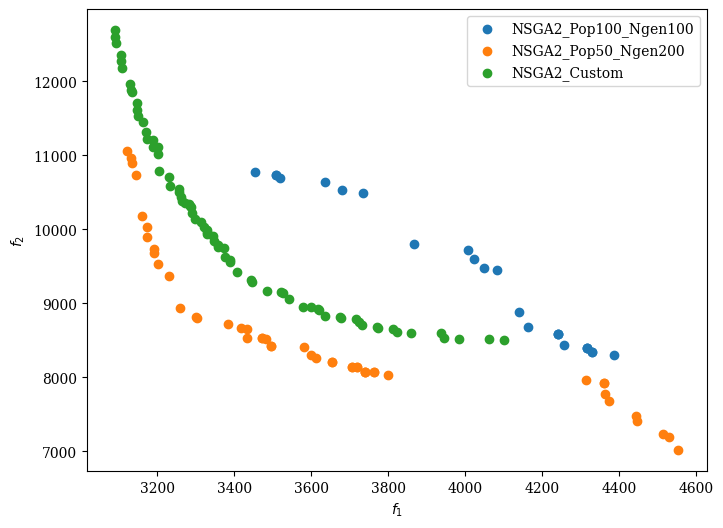

In [30]:
scatter = Scatter()
scatter.add(res_batir_1.F, label="NSGA2_Pop100_Ngen100")
scatter.add(res_batir_2.F, label="NSGA2_Pop50_Ngen200")
scatter.add(res_1.F, label="NSGA2_Custom")
scatter.legend = True
scatter.show()

# Improvements

In [12]:
# Importar operadores específicos para problemas de permutación (TSP)
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions

# Crear el problema TSP
problem_improved = TSPProblem(n_cities=100, seed=42)

# Configurar NSGA-II con operadores específicos para TSP
nsga2_custom = NSGA2(
    pop_size=100,
    sampling=PermutationRandomSampling(),      # Muestreo aleatorio de permutaciones
    crossover=OrderCrossover(prob=0.9),         # Order Crossover (ideal para TSP)
    mutation=InversionMutation(prob=0.1),       # Mutación por inversión
    eliminate_duplicates=True
)

# Ejecutar NSGA-II personalizado
res_custom = minimize(
    problem_improved,
    nsga2_custom,
    ("n_gen", 150),
    seed=42,
    verbose=False
)

print(f"Soluciones en el frente de Pareto (NSGA-II Custom): {len(res_custom.F)}")
print(f"Mejor distancia encontrada: {res_custom.F[:, 0].min():.2f}")
print(f"Mejor tiempo encontrado: {res_custom.F[:, 1].min():.2f}")

Soluciones en el frente de Pareto (NSGA-II Custom): 30
Mejor distancia encontrada: 3613.10
Mejor tiempo encontrado: 10180.84


In [17]:
# Configurar NSGA-III con direcciones de referencia (mejor para muchos objetivos)
ref_dirs = get_reference_directions("das-dennis", 2, n_partitions=12)

nsga3_custom = NSGA3(
    pop_size=100,
    ref_dirs=ref_dirs,
    sampling=PermutationRandomSampling(),
    crossover=OrderCrossover(prob=0.9),
    mutation=InversionMutation(prob=0.15),
    eliminate_duplicates=True
)

# Ejecutar NSGA-III
res_nsga3 = minimize(
    problem_improved,
    nsga3_custom,
    ("n_eval", 100000),
    seed=42,
    verbose=False,
)

print(f"Soluciones en el frente de Pareto (NSGA-III): {len(res_nsga3.F)}")
print(f"Mejor distancia encontrada: {res_nsga3.F[:, 0].min():.2f}")
print(f"Mejor tiempo encontrado: {res_nsga3.F[:, 1].min():.2f}")

Soluciones en el frente de Pareto (NSGA-III): 8
Mejor distancia encontrada: 3016.19
Mejor tiempo encontrado: 7656.55


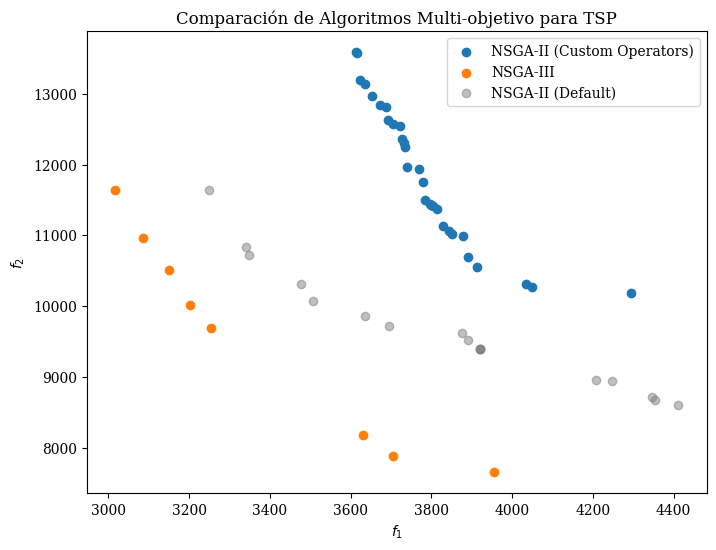

In [18]:
# Comparación visual de los frentes de Pareto
scatter_comparison = Scatter(title="Comparación de Algoritmos Multi-objetivo para TSP")
scatter_comparison.add(res_custom.F, label="NSGA-II (Custom Operators)")
scatter_comparison.add(res_nsga3.F, label="NSGA-III")
scatter_comparison.add(res.F, label="NSGA-II (Default)", color="gray", alpha=0.5)
scatter_comparison.legend = True
scatter_comparison.show()

In [ ]:
# Calcular métricas de calidad: Hypervolume
from pymoo.indicators.hv import HV

# Punto de referencia para el hipervolumen (peor caso)
ref_point = np.array([5000, 15000])

# Calcular hipervolumen para cada algoritmo
hv_indicator = HV(ref_point=ref_point)

hv_default = hv_indicator(res.F)
hv_custom = hv_indicator(res_custom.F)
hv_nsga3 = hv_indicator(res_nsga3.F)

print("=== Comparación de Hipervolumen (mayor es mejor) ===")
print(f"NSGA-II (Default):          {hv_default:.2e}")
print(f"NSGA-II (Custom Operators): {hv_custom:.2e}")
print(f"NSGA-III:                   {hv_nsga3:.2e}")
print(f"\nMejor algoritmo: ", end="")
best_hv = max(hv_default, hv_custom, hv_nsga3)
if best_hv == hv_default:
    print("NSGA-II (Default)")
elif best_hv == hv_custom:
    print("NSGA-II (Custom Operators)")
else:
    print("NSGA-III")